In [ ]:
# Import required libraries
import pandas as pd
import os
from scipy import stats
from scipy.stats import wilcoxon
import numpy as np
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from scipy.stats import ttest_1samp
from datetime import datetime
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Read large building intersection
# duplication.csv can be found in the folder Data Analysis/Data
data_folder = "/content/drive/Shareddrives/OSM-ODECO/HOTOSM/inconsistency/continuation/"
inputfile = os.path.join(data_folder, "duplication.csv")
df = pd.read_csv(inputfile)
df["area"]=df["area_of_shrunk_grids"]+df["area_of_border_buffer"]
df["nodes"]=df["nodes_in_shrunk_grids"]+df["nodes_in_border_buffer"]
df

,project_id,grid_type,shrink_distance,shrink_type,nodes_in_shrunk_grids,nodes_in_border_buffer,area_of_shrunk_grids,area_of_border_buffer,nodes_per_area_shrunk_grids,nodes_per_area_border_buffer,area,nodes
0,105,MOCKUP,5,percentage,215,12,4.304850e+07,2.231740e+06,0.000005,5.376972e-06,4.528024e+07,227
1,105,MOCKUP,10,percentage,208,19,4.078661e+07,4.493630e+06,0.000005,4.228207e-06,4.528024e+07,227
2,105,MOCKUP,15,percentage,205,22,3.852519e+07,6.755050e+06,0.000005,3.256823e-06,4.528024e+07,227
3,105,ORIGINAL,1,percentage,226,1,4.478634e+07,4.939011e+05,0.000005,2.024697e-06,4.528024e+07,227
4,105,ORIGINAL,2,percentage,224,3,4.440017e+07,8.800662e+05,0.000005,3.408835e-06,4.528024e+07,227
...,...,...,...,...,...,...,...,...,...,...,...,...
440214,17269,ORIGINAL,96,percentage,0,1,9.078135e+04,1.533452e+06,0.000000,6.521233e-07,1.624234e+06,1
440215,17269,ORIGINAL,97,percentage,0,1,4.870092e+04,1.575533e+06,0.000000,6.347059e-07,1.624234e+06,1
440216,17269,ORIGINAL,98,percentage,0,1,3.262537e+04,1.591608e+06,0.000000,6.282953e-07,1.624234e+06,1
440217,17269,ORIGINAL,99,percentage,0,1,2.687676e+04,1.597357e+06,0.000000,6.260342e-07,1.624234e+06,1


In [ ]:
# Projects with positive count
dfkw=df[df["nodes"]>0]
dfkw["nodes_per_buffer"]=dfkw["nodes_in_border_buffer"]/dfkw["nodes"]*100
dfkw["area_in_border_per"]=dfkw["area_of_border_buffer"]/dfkw["area"]*100
dfkw["nodes_per_buffer"]=dfkw["nodes_per_buffer"]*dfkw["shrink_distance"]/dfkw["area_in_border_per"]

/tmp/ipython-input-3-53024173.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfkw["nodes_per_buffer"]=dfkw["nodes_in_border_buffer"]/dfkw["nodes"]*100
/tmp/ipython-input-3-53024173.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfkw["area_in_border_per"]=dfkw["area_of_border_buffer"]/dfkw["area"]*100
/tmp/ipython-input-3-53024173.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

# 1. Characterization of areas: edge and random (5%, 10%, 15%)

In [ ]:
## Area at 5%

In [ ]:
# Describe nodes around the edge with 5%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="ORIGINAL"][dfkw["shrink_distance"]==5].describe()

,nodes_per_buffer
count,2104.000000
mean,19.048452
std,23.925279
min,0.000000
25%,0.000000
50%,8.446432
75%,28.137989
max,113.872734


In [ ]:
# Describe nodes in random area with 5%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="MOCKUP"][dfkw["shrink_distance"]==5].describe()

,nodes_per_buffer
count,2104.000000
mean,5.270493
std,12.815862
min,0.000000
25%,0.000000
50%,0.000000
75%,5.970267
max,101.735628


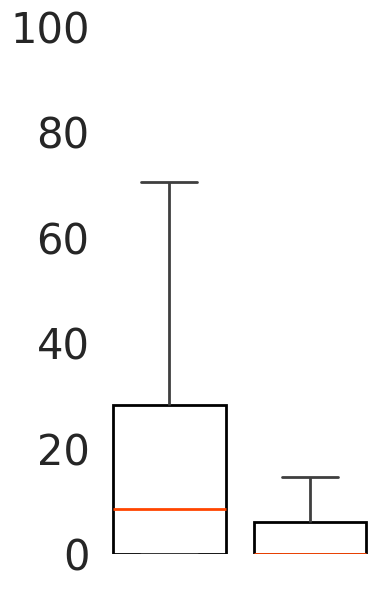

In [ ]:
# Plot distribution of nodes for edge and random areas at 5%
# Filter the data where shrink_distance == 5
filtered_df = dfkw[dfkw["shrink_distance"]==5][["grid_type","nodes_per_buffer"]]
# Get the reversed order of grid types
unique_types = filtered_df["grid_type"].unique()
reversed_order = list(reversed(unique_types))
# Set up the figure
plt.figure(figsize=(4, 6))
sns.set_style("white")
# Create the boxplot
ax = sns.boxplot(
    x="grid_type",
    y="nodes_per_buffer",
    data=filtered_df,
    order=reversed_order,
    width=0.8,
    linewidth=2,
    showfliers=False,
    boxprops=dict(edgecolor="black", facecolor="white"),
    medianprops=dict(color="#FF4500", linewidth=2)
)
# Set vertical axis limits
ax.set_ylim(0, 100)
# Remove background and X axis elements
sns.despine(left=True, bottom=True)
ax.set(xlabel=None, ylabel=None)
ax.set_xticks([])  # Remove x-axis ticks
ax.tick_params(axis='y', labelsize=30)  # Show y-axis ticks
# Final layout adjustments
plt.tight_layout()
plt.show()

In [ ]:
# t-test to check if the % of nodes in edge areas is different from 5%
# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "ORIGINAL") & (dfkw["shrink_distance"] == 5), "nodes_per_buffer"]
# Perform one-sample t-test against population mean = 5
t_test_result = ttest_1samp(filtered, popmean=5)
# Print result
print(t_test_result)

TtestResult(statistic=np.float64(26.93359410666495), pvalue=np.float64(1.594698892627872e-137), df=np.int64(2103))


In [ ]:
# t-test to check if the % of nodes in random areas is different from 5%
# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "MOCKUP") & (dfkw["shrink_distance"] == 5), "nodes_per_buffer"]
# Perform one-sample t-test against population mean = 5
t_test_result = ttest_1samp(filtered, popmean=5)
# Print result
print(t_test_result)

TtestResult(statistic=np.float64(0.9681251638577593), pvalue=np.float64(0.3330931872431395), df=np.int64(2103))


## Area at 10%

In [ ]:
# Describe nodes around the edge with 10%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="ORIGINAL"][dfkw["shrink_distance"]==10].describe()

,nodes_per_buffer
count,2104.000000
mean,32.249227
std,35.093625
min,0.000000
25%,0.000000
50%,18.165180
75%,51.270179
max,120.879836


In [ ]:
# Describe nodes in random area with 10%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="MOCKUP"][dfkw["shrink_distance"]==10].describe()

,nodes_per_buffer
count,2104.000000
mean,9.965301
std,16.193842
min,0.000000
25%,0.000000
50%,5.601968
75%,12.603699
max,100.968275


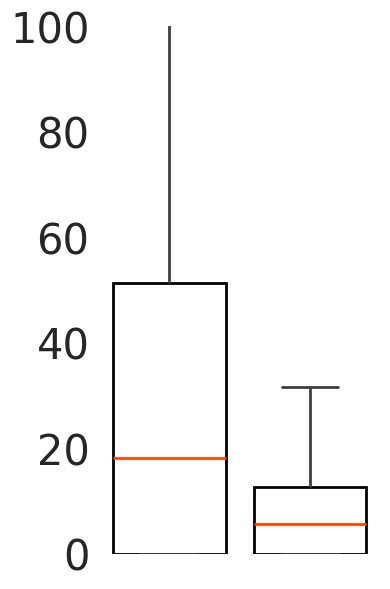

In [ ]:
# Plot distribution of nodes for edge and random areas at 10%
# Filter the data where shrink_distance == 10
filtered_df = dfkw[dfkw["shrink_distance"]==10][["grid_type","nodes_per_buffer"]]
# Get the reversed order of grid types
unique_types = filtered_df["grid_type"].unique()
reversed_order = list(reversed(unique_types))
# Set up the figure
plt.figure(figsize=(4, 6))
sns.set_style("white")
# Create the boxplot
ax = sns.boxplot(
    x="grid_type",
    y="nodes_per_buffer",
    data=filtered_df,
    order=reversed_order,
    width=0.8,
    linewidth=2,
    showfliers=False,
    boxprops=dict(edgecolor="black", facecolor="white"),
    medianprops=dict(color="#FF4500", linewidth=2)
)
# Set vertical axis limits
ax.set_ylim(0, 100)
# Remove background and X axis elements
sns.despine(left=True, bottom=True)
ax.set(xlabel=None, ylabel=None)
ax.set_xticks([])  # Remove x-axis ticks
ax.tick_params(axis='y', labelsize=30)  # Show y-axis ticks
# Final layout adjustments
plt.tight_layout()
plt.show()

In [ ]:
# t-test to check if the % of nodes in edge areas is different from 10%
# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "ORIGINAL") & (dfkw["shrink_distance"] == 10), "nodes_per_buffer"]
# Perform one-sample t-test against population mean = 10
t_test_result = ttest_1samp(filtered, popmean=10)
# Print result
print(t_test_result)

TtestResult(statistic=np.float64(29.081014963071), pvalue=np.float64(1.4429534807016697e-156), df=np.int64(2103))


In [ ]:
# t-test to check if the % of nodes in random areas is different from 10%
# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "MOCKUP") & (dfkw["shrink_distance"] == 10), "nodes_per_buffer"]
# Perform one-sample t-test against population mean = 10
t_test_result = ttest_1samp(filtered, popmean=10)
# Print result
print(t_test_result)

TtestResult(statistic=np.float64(-0.0982854735955731), pvalue=np.float64(0.9217149793147181), df=np.int64(2103))


## Area at 15%

In [ ]:
# Describe nodes around the edge with 15%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="ORIGINAL"][dfkw["shrink_distance"]==15].describe()

,nodes_per_buffer
count,2104.000000
mean,39.068862
std,35.725880
min,0.000000
25%,9.205087
50%,28.299077
75%,66.020071
max,102.653271


In [ ]:
# Describe nodes in random area with 15%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="MOCKUP"][dfkw["shrink_distance"]==15].describe()

,nodes_per_buffer
count,2104.000000
mean,15.576594
std,20.586508
min,0.000000
25%,0.000000
50%,12.255010
75%,20.105734
max,100.661543


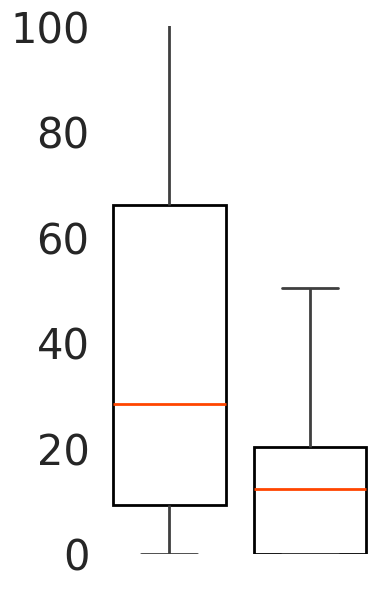

In [ ]:
# Plot distribution of nodes for edge and random areas at 15%
# Filter the data where shrink_distance == 15
filtered_df = dfkw[dfkw["shrink_distance"]==15][["grid_type","nodes_per_buffer"]]
# Get the reversed order of grid types
unique_types = filtered_df["grid_type"].unique()
reversed_order = list(reversed(unique_types))
# Set up the figure
plt.figure(figsize=(4, 6))
sns.set_style("white")
# Create the boxplot
ax = sns.boxplot(
    x="grid_type",
    y="nodes_per_buffer",
    data=filtered_df,
    order=reversed_order,
    width=0.8,
    linewidth=2,
    showfliers=False,
    boxprops=dict(edgecolor="black", facecolor="white"),
    medianprops=dict(color="#FF4500", linewidth=2)
)
# Set vertical axis limits
ax.set_ylim(0, 100)
# Remove background and X axis elements
sns.despine(left=True, bottom=True)
ax.set(xlabel=None, ylabel=None)
ax.set_xticks([])  # Remove x-axis ticks
ax.tick_params(axis='y', labelsize=30)  # Show y-axis ticks
# Final layout adjustments
plt.tight_layout()
plt.show()

In [ ]:
# t-test to check if the % of nodes in edge areas is different from 15%
# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "ORIGINAL") & (dfkw["shrink_distance"] == 15), "nodes_per_buffer"]
# Perform one-sample t-test against population mean = 15
t_test_result = ttest_1samp(filtered, popmean=15)
# Print result
print(t_test_result)

TtestResult(statistic=np.float64(30.902633332277087), pvalue=np.float64(3.348040059717661e-173), df=np.int64(2103))


In [ ]:
# t-test to check if the % of nodes in random areas is different from 15%
# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "MOCKUP") & (dfkw["shrink_distance"] == 15), "nodes_per_buffer"]
# Perform one-sample t-test against population mean = 15
t_test_result = ttest_1samp(filtered, popmean=15)
# Print result
print(t_test_result)

TtestResult(statistic=np.float64(1.2847248403336027), pvalue=np.float64(0.19902994335215765), df=np.int64(2103))


# 2. Profiling the difference between the observed and expected proportion of nodes ('Difference') and its rate of change ('Change') as a function of edge area at 5% increments


In [ ]:
# Read large building intersection data for multiple area configurations
data_folder = "/content/drive/Shareddrives/OSM-ODECO/HOTOSM/inconsistency/continuation/"
inputfile = os.path.join(data_folder, "duplicationtotal.csv")
curve = pd.read_csv(inputfile)
curve["area"]=curve["area_of_shrunk_grids"]+curve["area_of_border_buffer"]
curve["nodes"]=curve["nodes_in_shrunk_grids"]+curve["nodes_in_border_buffer"]
curve=curve[curve["nodes"]>0][curve["grid_type"]=="ORIGINAL"][curve["shrink_distance"]>15]
curve["nodes_per_buffer"]=curve["nodes_in_border_buffer"]/curve["nodes"]*100
curve["area_in_border_per"]=curve["area_of_border_buffer"]/curve["area"]*100
curve["nodes_per_buffer"]=curve["nodes_per_buffer"]*curve["shrink_distance"]/curve["area_in_border_per"]
curve.loc[curve["nodes_per_buffer"] > 100, "nodes_per_buffer"] = 100
curve = pd.concat([curve, dfkw[dfkw["nodes"]>0][dfkw["grid_type"]=="ORIGINAL"]] )
curve["diff"]=(curve["nodes_per_buffer"]-curve["shrink_distance"])
curve=curve[curve["shrink_distance"].isin([5,10,15,20,25,30,35,40,45,50,55,60,65,70,74,80,85,90,95,100])]
curve

/tmp/ipython-input-20-1924208253.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  curve=curve[curve["nodes"]>0][curve["grid_type"]=="ORIGINAL"][curve["shrink_distance"]>15]
/tmp/ipython-input-20-1924208253.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  curve=curve[curve["nodes"]>0][curve["grid_type"]=="ORIGINAL"][curve["shrink_distance"]>15]


,project_id,grid_type,shrink_distance,shrink_type,nodes_in_shrunk_grids,nodes_in_border_buffer,area_of_shrunk_grids,area_of_border_buffer,nodes_per_area_shrunk_grids,nodes_per_area_border_buffer,area,nodes,nodes_per_buffer,area_in_border_per,diff
22,105,ORIGINAL,20,percentage,195,32,3.616931e+07,9.110931e+06,0.000005,3.512264e-06,4.528024e+07,227,14.011997,20.121209,-5.988003
27,105,ORIGINAL,25,percentage,188,39,3.417413e+07,1.110610e+07,0.000006,3.511582e-06,4.528024e+07,227,17.511595,24.527487,-7.488405
32,105,ORIGINAL,30,percentage,178,49,3.167094e+07,1.360929e+07,0.000006,3.600481e-06,4.528024e+07,227,21.545896,30.055705,-8.454104
37,105,ORIGINAL,35,percentage,170,57,2.920610e+07,1.607414e+07,0.000006,3.546069e-06,4.528024e+07,227,24.757000,35.499238,-10.243000
42,105,ORIGINAL,40,percentage,165,62,2.716892e+07,1.811131e+07,0.000006,3.423274e-06,4.528024e+07,227,27.313952,39.998277,-12.686048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440198,17269,ORIGINAL,80,percentage,0,1,3.244674e+05,1.299766e+06,0.000000,7.693691e-07,1.624234e+06,1,99.970811,80.023358,19.970811
440203,17269,ORIGINAL,85,percentage,0,1,2.388110e+05,1.385423e+06,0.000000,7.218014e-07,1.624234e+06,1,99.651798,85.297006,14.651798
440208,17269,ORIGINAL,90,percentage,0,1,1.625548e+05,1.461679e+06,0.000000,6.841448e-07,1.624234e+06,1,100.008992,89.991908,10.008992
440213,17269,ORIGINAL,95,percentage,0,1,8.111068e+04,1.543123e+06,0.000000,6.480365e-07,1.624234e+06,1,99.993455,95.006218,4.993455


In [ ]:
# Calculate mean and median difference between the observed and expected proportion of nodes at varying area configurations
curvetable=curve.groupby(curve.shrink_distance).agg({'diff': ['median',"mean"]})
flat_cols = []

# iterate through this tuples and
# join them as single string
for i in curvetable.columns:
    flat_cols.append(i[0]+'_'+i[1])

# now assign the list of flattened
# columns to the grouped columns.
curvetable.columns = flat_cols
curvetable

,diff_median,diff_mean
shrink_distance,,
5,3.446432,14.048452
10,8.165180,22.249227
15,13.299077,24.068862
20,15.443931,23.895752
25,18.086763,23.551110
30,19.904292,22.239085
35,17.674751,20.746813
40,19.978880,19.564823
45,21.059668,18.132694


<Axes: xlabel='shrink_distance'>

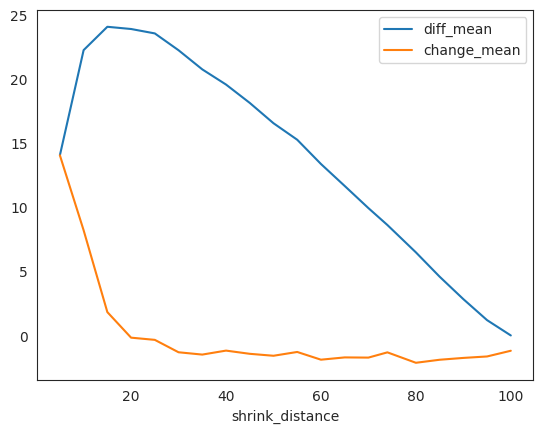

In [ ]:
# Plot the difference between the observed and expected proportion of nodes ('Difference') and its rate of change ('Change') as a function of edge area at 5% increments
curvetable["change_median"]=curvetable["diff_median"]-curvetable["diff_median"].shift()
curvetable["change_mean"]=curvetable["diff_mean"]-curvetable["diff_mean"].shift()
curve.loc[curve["nodes_per_buffer"] > 100, "nodes_per_buffer"] = 100
curvetable.reset_index()
curvetable['change_median'] = curvetable['change_median'].fillna(3.446432)
curvetable['change_mean'] = curvetable['change_mean'].fillna(14.048452)
curvetable[["diff_mean","change_mean"]].plot()

In [ ]:
border=[0.010102051443364402,
0.02303039929152717,
0.036319075225214825,
0.04999999999999999,
0.06411010564593267,
0.0786925113411821,
0.09379807976820198,
0.10948751620466729,
0.12583426132260583,
0.1429285785728575,
0.1608835008437366,
0.17984378812835755,
0.2,
0.2216117818584989,
0.24504902432036074,
0.27087121525220803,
0.3,
0.33416876048223,
0.377525512860841,
0.44999999999999996]
# Add border for plotting
curvetable['border']=border

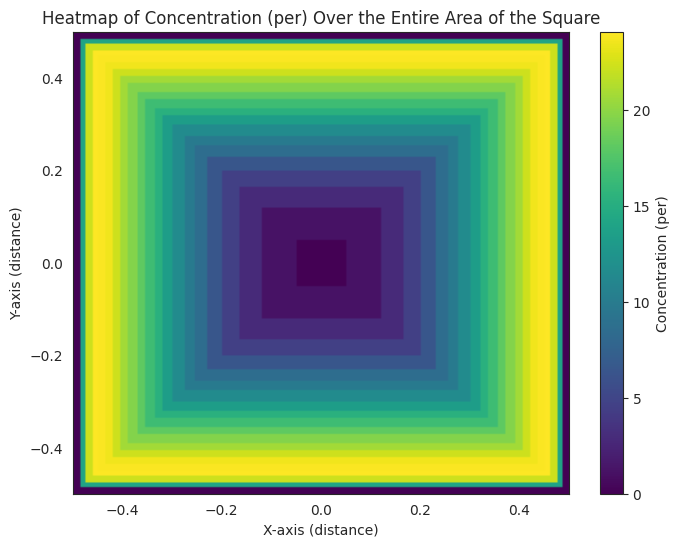

In [ ]:
# Plot the difference between the observed and expected proportion of nodes ('Difference') as a heatmap
# Assume 'data' is your DataFrame with columns 'd' and 'per'
d = curvetable['border']
per = curvetable['diff_mean']

# Create a grid representing the square area
square_size = 1  # Assume the square size is normalized to 1 for simplicity
grid_size = 200
x = np.linspace(-square_size/2, square_size/2, grid_size)
y = np.linspace(-square_size/2, square_size/2, grid_size)
X, Y = np.meshgrid(x, y)

# Define the area based on 'd' and assign 'per' values uniformly across each area
Z = np.zeros_like(X)

# Loop through each 'd' value and apply the corresponding 'per' across the area
for margin, concentration in zip(d, per):
    mask = (np.abs(X) <= square_size/2 - margin) & (np.abs(Y) <= square_size/2 - margin)
    Z[mask] = concentration

# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(Z, extent=[-square_size/2, square_size/2, -square_size/2, square_size/2], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='Concentration (per)')
plt.title('Heatmap of Concentration (per) Over the Entire Area of the Square')
plt.xlabel('X-axis (distance)')
plt.ylabel('Y-axis (distance)')
#plt.grid(True)
plt.show()

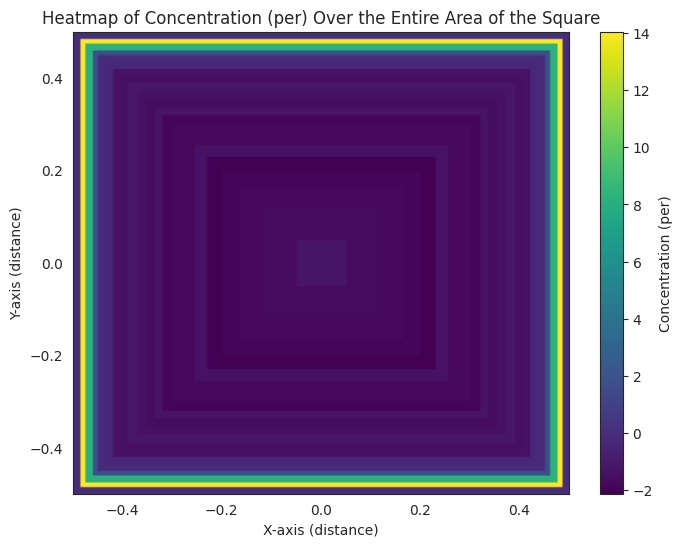

In [ ]:
# Plot the difference between the rate of change ('Change') as a heatmap
# Assume 'data' is your DataFrame with columns 'd' and 'per'
d = curvetable['border']
per = curvetable['change_mean']

# Create a grid representing the square area
square_size = 1  # Assume the square size is normalized to 1 for simplicity
grid_size = 200
x = np.linspace(-square_size/2, square_size/2, grid_size)
y = np.linspace(-square_size/2, square_size/2, grid_size)
X, Y = np.meshgrid(x, y)

# Define the area based on 'd' and assign 'per' values uniformly across each area
Z = np.zeros_like(X)

# Loop through each 'd' value and apply the corresponding 'per' across the area
for margin, concentration in zip(d, per):
    mask = (np.abs(X) <= square_size/2 - margin) & (np.abs(Y) <= square_size/2 - margin)
    Z[mask] = concentration

# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(Z, extent=[-square_size/2, square_size/2, -square_size/2, square_size/2], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='Concentration (per)')
plt.title('Heatmap of Concentration (per) Over the Entire Area of the Square')
plt.xlabel('X-axis (distance)')
plt.ylabel('Y-axis (distance)')
#plt.grid(True)
plt.show()

# 3. Regression analysis of the edge effect (diff)

In [ ]:
# Read data about projects
data_folder = "/content/drive/Shareddrives/OSM-ODECO/HOTOSM/inconsistency/continuation/"
inputfile = os.path.join(data_folder, "TotalProjects.xlsx")
projects = pd.read_excel(inputfile)
projects['difficulty'] = projects['difficulty'].map({'EASY': '1. EASY','MODERATE': '2. MODERATE', 'CHALLENGING': '3. CHALLENGING'})
projects['priority'] = projects['priority'].map({'LOW': '1. LOW','MEDIUM': '2. MEDIUM', 'HIGH': '3. HIGH', 'URGENT': '4. URGENT'})
projects

,projectId,difficulty,priority,percentValidated,totalContributors,totalAreaSquareKilometers,creationDate,totalTasks
0,95,1. EASY,2. MEDIUM,0,6,681.215000,2012-11-14T04:33:43.416846Z,NaN
1,96,1. EASY,2. MEDIUM,37,5,23.946000,2012-11-19T02:24:05.193592Z,NaN
2,98,1. EASY,2. MEDIUM,0,23,1118.086000,2012-11-28T09:26:47.116782Z,NaN
3,99,1. EASY,2. MEDIUM,17,31,0.837000,2012-11-29T16:42:24.810129Z,NaN
4,100,1. EASY,2. MEDIUM,0,7,205.908000,2012-12-01T12:14:12.186123Z,NaN
...,...,...,...,...,...,...,...,...
11890,17252,1. EASY,1. LOW,3,7,175.443935,2024-07-22T12:49:10.268139Z,147.0
11891,17021,1. EASY,2. MEDIUM,0,4,4066.856579,2024-06-16T08:00:44.755468Z,22.0
11892,17202,NaN,NaN,0,5,2929.558903,NaN,170.0
11893,17229,NaN,NaN,6,4,1142.439222,NaN,80.0


In [ ]:
# Filter data for bordar at 20% where difference is maximized
curve=curve[curve["grid_type"]=="ORIGINAL"][curve["shrink_distance"]==20].merge(projects, left_on="project_id", right_on="projectId")
curve["diff"]=(curve["nodes_per_buffer"]-curve["shrink_distance"])
curve

,project_id,grid_type,shrink_distance,shrink_type,nodes_in_shrunk_grids,nodes_in_border_buffer,area_of_shrunk_grids,area_of_border_buffer,nodes_per_area_shrunk_grids,nodes_per_area_border_buffer,...,area_in_border_per,diff,projectId,difficulty,priority,percentValidated,totalContributors,totalAreaSquareKilometers,creationDate,totalTasks
0,105,ORIGINAL,20,percentage,195,32,3.616931e+07,9.110931e+06,5.391312e-06,3.512264e-06,...,20.121209,-5.988003,105,1. EASY,2. MEDIUM,100,434,35.033,2012-12-06T02:07:21.732546Z,151.0
1,210,ORIGINAL,20,percentage,11,1,1.231507e+09,3.102121e+08,8.932144e-09,3.223601e-09,...,20.121179,-11.716854,210,1. EASY,2. MEDIUM,98,264,944.942,2013-03-13T19:28:14.503117Z,123.0
2,213,ORIGINAL,20,percentage,1,0,1.389499e+06,3.500104e+05,7.196838e-07,0.000000e+00,...,20.121215,-20.000000,213,1. EASY,2. MEDIUM,100,201,1.244,2013-03-20T15:04:53.108052Z,105.0
3,295,ORIGINAL,20,percentage,1,1,8.626615e+06,2.173017e+06,1.159203e-07,4.601897e-07,...,20.121212,29.698797,295,1. EASY,2. MEDIUM,100,5,9.079,2013-08-16T07:35:16.003496Z,117.0
4,297,ORIGINAL,20,percentage,0,1,3.066788e+07,7.725141e+06,0.000000e+00,1.294475e-07,...,20.121212,79.397589,297,1. EASY,2. MEDIUM,30,17,35.155,2013-08-19T02:48:12.642978Z,416.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4203,17033,ORIGINAL,20,percentage,1,4,1.430086e+06,3.590004e+05,6.992587e-07,1.114205e-05,...,20.066130,59.736350,17033,2. MODERATE,3. HIGH,100,17,1.788,2024-06-24T08:15:45.295358Z,30.0
4204,17035,ORIGINAL,20,percentage,1,5,9.210767e+05,2.315223e+05,1.085686e-06,2.159619e-05,...,20.086978,62.972493,17035,2. MODERATE,3. HIGH,100,22,1.152,2024-06-24T08:50:55.797105Z,20.0
4205,17036,ORIGINAL,20,percentage,0,1,6.808464e+05,1.710311e+05,0.000000e+00,5.846890e-06,...,20.076959,79.616678,17036,2. MODERATE,3. HIGH,100,12,0.851,2024-06-24T09:07:02.827306Z,19.0
4206,17089,ORIGINAL,20,percentage,3,2,2.874935e+06,7.217813e+05,1.043502e-06,2.770922e-06,...,20.067786,19.864886,17089,2. MODERATE,1. LOW,100,30,3.592,2024-06-29T08:40:02.092618Z,101.0


In [ ]:
# Date preprocessing
curve['creationDate'] = pd.to_datetime(curve['creationDate'], errors='coerce')
curve['creationDate'] = curve['creationDate'].dt.tz_localize(None)
current_date = datetime.now()
curve['months_since_creation'] = curve['creationDate'].apply(lambda x: (current_date - x).days / 30 if pd.notnull(x) else np.nan)
# Variable selection and data cleaning
variables = [
    'totalAreaSquareKilometers',
    'totalContributors',
    'months_since_creation',
    'percentValidated',
    'priority',
    'difficulty',
    'diff',
    "totalTasks"
]
df_clean = curve[variables].dropna()
# Logarithmic transformations
df_clean['log_totalContributors'] = np.log1p(df_clean['totalContributors'])
df_clean['log_totalTasks'] = np.log1p(df_clean['totalTasks'])
df_clean['contributorspertask'] = df_clean['totalContributors'] / df_clean['totalTasks']
df_clean['log_totalAreaSquareKilometerspertask'] = np.log1p(df_clean['totalAreaSquareKilometers']/ df_clean['totalTasks'])
# Define predictors and dependent variable
X = df_clean[['log_totalTasks','log_totalAreaSquareKilometerspertask', 'contributorspertask', 'months_since_creation',
              'percentValidated', 'priority', 'difficulty']]
y = df_clean['diff']
# Convert categorical variables to dummy variables
X = pd.get_dummies(X, columns=['priority', 'difficulty'], drop_first=True, dtype=float)
# Convert object columns to numeric
for col in X.select_dtypes(include=['object']).columns:
    # You might need to adjust 'coerce' to 'raise' if you want to be stricter with errors.
    X[col] = pd.to_numeric(X[col], errors='coerce')
# Add constant
X = sm.add_constant(X)
# Fit the model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   diff   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     28.12
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           1.02e-52
Time:                        17:32:06   Log-Likelihood:                -20817.
No. Observations:                4208   AIC:                         4.166e+04
Df Residuals:                    4197   BIC:                         4.173e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
